In [139]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from itertools import combinations
from math import comb
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,roc_auc_score,r2_score

In [140]:
Data=pd.read_csv("stroke_triage.csv")
#display(Data.head())

display(Data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2000 non-null   float64
 1   systolic_bp        2000 non-null   float64
 2   diastolic_bp       2000 non-null   float64
 3   glucose            2000 non-null   float64
 4   cholesterol        2000 non-null   float64
 5   heart_rate         2000 non-null   float64
 6   spo2               2000 non-null   float64
 7   bmi                2000 non-null   float64
 8   smoker             2000 non-null   int64  
 9   diabetes_history   2000 non-null   int64  
 10  stroke_risk_label  2000 non-null   int64  
 11  batch_id           2000 non-null   int64  
dtypes: float64(8), int64(4)
memory usage: 187.6 KB


None

In [141]:
Features=["age",
    "systolic_bp",
    "diastolic_bp",
    "glucose",
    "cholesterol",
    "heart_rate",
    "spo2",
    "bmi",
    "smoker",
    "diabetes_history"
]

X=Data[Features].values
y=Data["stroke_risk_label"].values

In [142]:
X_Train,X_Temp,Y_Train,Y_Temp=train_test_split(X,y,test_size=0.4,shuffle=True,random_state=42)
X_Val,X_Test,Y_Val,Y_Test=train_test_split(X_Temp,Y_Temp,test_size=0.5,shuffle=True,random_state=42)

print(f"Train : {X_Train.shape}")
print(f"Validation : {X_Val.shape}")
print(f"Test : {X_Test.shape}")

Train : (1200, 10)
Validation : (400, 10)
Test : (400, 10)


In [143]:
Scaler=StandardScaler()
X_Train=Scaler.fit_transform(X_Train)
X_Val=Scaler.transform(X_Val)  
X_Test=Scaler.transform(X_Test) 

In [144]:
X_Train=torch.FloatTensor(X_Train)
Y_Train=torch.FloatTensor(Y_Train).unsqueeze(1)

X_Val=torch.FloatTensor(X_Val)
Y_Val=torch.FloatTensor(Y_Val).unsqueeze(1)

X_Test=torch.FloatTensor(X_Test)
Y_Test=torch.FloatTensor(Y_Test).unsqueeze(1)

In [145]:
class Assignment1NN(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(Assignment1NN, self).__init__()
        self.model=nn.Sequential(
            nn.Linear(10, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, X):
        return self.model(X)

Model=Assignment1NN(dropout_rate=0.3)

In [146]:
Criterion=nn.BCELoss()
Optimizer=torch.optim.Adam(Model.parameters(), lr=0.001, weight_decay=1e-4)

In [147]:
Epochs=250
patience=30
best_val_loss=float('inf')
patience_counter=0
best_epoch=0

Train_Losses=[]
Val_Losses=[]

for epoch in range(Epochs):
    
    Model.train()
    Optimizer.zero_grad()
    outputs=Model(X_Train)
    loss=Criterion(outputs, Y_Train)
    loss.backward()
    Optimizer.step()
    Train_Losses.append(loss.item())

    
    Model.eval()
    with torch.no_grad():
        val_outputs=Model(X_Val)
        val_loss=Criterion(val_outputs,Y_Val)
        Val_Losses.append(val_loss.item())

    
    if (val_loss.item()<best_val_loss):
        best_val_loss=val_loss.item()
        patience_counter=0
        best_epoch=epoch
        torch.save(Model.state_dict(),'Best_Model.pth')
    else:
        patience_counter+=1
        if patience_counter>=patience:
            print(f"Early stopping at epoch {epoch+1}. Best epoch: {best_epoch+1}")
            break

    if ((epoch + 1) % 10 == 0):
        print(f"Epoch {epoch+1}/{Epochs}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, Patience: {patience_counter}/{patience}")

Epoch 10/250, Train Loss: 0.7038, Val Loss: 0.7319, Patience: 0/30
Epoch 20/250, Train Loss: 0.6680, Val Loss: 0.6853, Patience: 0/30
Epoch 30/250, Train Loss: 0.6436, Val Loss: 0.6450, Patience: 0/30
Epoch 40/250, Train Loss: 0.6243, Val Loss: 0.6173, Patience: 0/30
Epoch 50/250, Train Loss: 0.6092, Val Loss: 0.5974, Patience: 0/30
Epoch 60/250, Train Loss: 0.5967, Val Loss: 0.5820, Patience: 0/30
Epoch 70/250, Train Loss: 0.5803, Val Loss: 0.5708, Patience: 0/30
Epoch 80/250, Train Loss: 0.5677, Val Loss: 0.5608, Patience: 0/30
Epoch 90/250, Train Loss: 0.5662, Val Loss: 0.5516, Patience: 0/30
Epoch 100/250, Train Loss: 0.5545, Val Loss: 0.5448, Patience: 0/30
Epoch 110/250, Train Loss: 0.5471, Val Loss: 0.5385, Patience: 0/30
Epoch 120/250, Train Loss: 0.5361, Val Loss: 0.5335, Patience: 0/30
Epoch 130/250, Train Loss: 0.5249, Val Loss: 0.5291, Patience: 0/30
Epoch 140/250, Train Loss: 0.5334, Val Loss: 0.5257, Patience: 0/30
Epoch 150/250, Train Loss: 0.5329, Val Loss: 0.5228, Pati

In [148]:
Model.eval()
with torch.no_grad():
    test_outputs=Model(X_Test)
    test_loss=Criterion(test_outputs, Y_Test)
    
    predictions=(test_outputs.numpy()>0.5).astype(int)
    test_predictions_proba=test_outputs.numpy()

print(f"\nTest Loss: {test_loss.item():.4f}")
print(f"Test Accuracy: {accuracy_score(Y_Test.numpy(), predictions)}")
print(f"Test Precision: {precision_score(Y_Test.numpy(), predictions, zero_division=0)}")
print(f"Test Recall: {recall_score(Y_Test.numpy(), predictions, zero_division=0)}")
print(f"Test AUC-ROC: {roc_auc_score(Y_Test.numpy(), test_predictions_proba)}")


Test Loss: 0.5147
Test Accuracy: 0.77
Test Precision: 0.8264984227129337
Test Recall: 0.8762541806020067
Test AUC-ROC: 0.7137984701480182


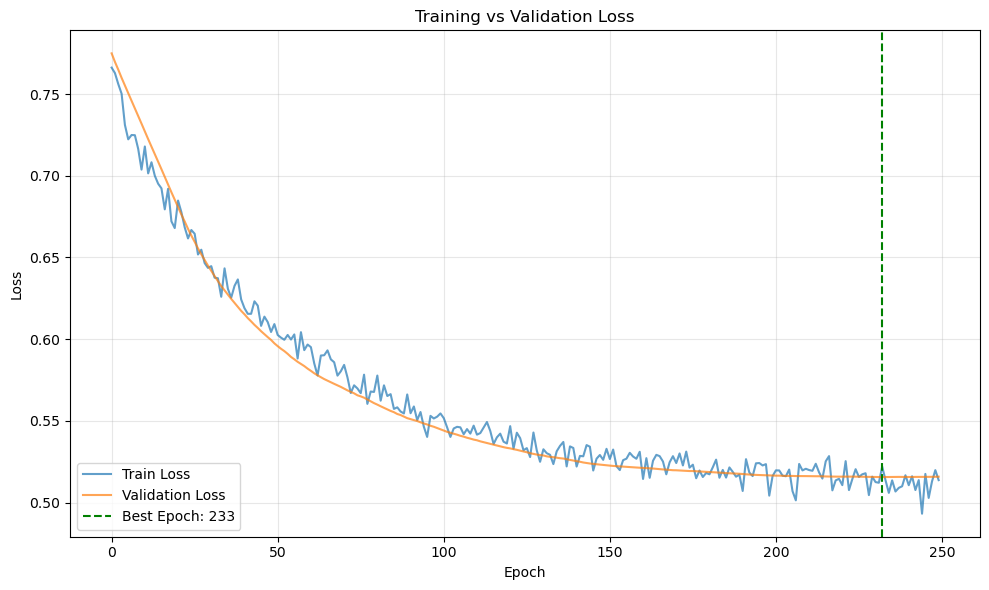

In [149]:
plt.figure(figsize=(10, 6))
plt.plot(Train_Losses, label='Train Loss', alpha=0.7)
plt.plot(Val_Losses, label='Validation Loss', alpha=0.7)
plt.axvline(x=best_epoch, color='green', linestyle='--', label=f'Best Epoch: {best_epoch+1}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=300)
plt.show()



In [150]:
np.random.seed(42)
Selected_Indices=np.random.choice(len(X_Test),10,replace=False)

X_Explain=X_Test[Selected_Indices]
Y_Explain=Y_Test[Selected_Indices]

print(f"Selected Indices Are : {Selected_Indices}.")

Selected Indices Are : [209 280  33 210  93  84 329  94 266 126].


In [151]:
np.save("X_Explain.npy",X_Explain.numpy())
np.save("Y_Explain.npy",Y_Explain.numpy())

In [152]:
def Compute_Bins(X_Train,N_Bins=4):
    Bin={}
    for Columns in range(X_Train.shape[1]):
        Bin[Columns]=np.percentile(X_Train[:,Columns],np.linspace(0,100,N_Bins+1))
    
    return Bin

Bins=Compute_Bins(X_Train.numpy())

In [153]:
def Discretize(X,Bins):
    X_Disc=np.zeros_like(X)
    for Column in range(X.shape[1]):
        X_Disc[:,Column]=np.digitize(X[:,Column],Bins[Column][1:-1])
    return X_Disc

In [154]:
def Generate_Perturbations(Instance,X_Train,Bins,N_Samples=500):
    N_Features=X_Train.shape[1]
    Samples=np.zeros((N_Samples,N_Features))

    for i in range(N_Samples):
        Perturbed=Instance.copy()

        for j in range(N_Features):
            if np.random.rand()<0.5:
                Perturbed[j]=np.random.choice(X_Train[:,j])
        
        Samples[i]=Perturbed

    return Samples

In [155]:
def Compute_Weights(Instance,Samples,Kernel_Width=1.0):
    Distances=np.linalg.norm(Samples-Instance,axis=1)
    Weights=np.exp(-(Distances**2)/(Kernel_Width**2))
    return Weights

In [156]:
def Fit_Weighted_Linear_Model(Samples,Predictions,Weights):
    Model=LinearRegression()
    Model.fit(Samples,Predictions,sample_weight=Weights)
    return Model

In [157]:
def LIME(Instance,Model,X_Train,Bins,N_Samples=500):
    Instance_Np=Instance.numpy()

    Samples=Generate_Perturbations(Instance_Np,
                                   X_Train.numpy(),
                                   Bins,N_Samples)
    
    Samples_Tensor=torch.FloatTensor(Samples)

    Model.eval()
    with torch.no_grad():
        Predictions=Model(Samples_Tensor).numpy().flatten()

    Weights=Compute_Weights(Instance_Np,Samples)

    Surrogate=Fit_Weighted_Linear_Model(Samples,Predictions,Weights)

    return Surrogate.coef_,Surrogate.intercept_

In [158]:
Features=["age",
    "systolic_bp",
    "diastolic_bp",
    "glucose",
    "cholesterol",
    "heart_rate",
    "spo2",
    "bmi",
    "smoker",
    "diabetes_history"
]

Explanations=[]

for i in range(len(X_Explain)):
    Coefs,Intercepts=LIME(X_Explain[i],Model,X_Train,Bins,N_Samples=500)

    Explanation=dict(zip(Features,Coefs))
    Explanations.append(Explanation)
    torch.save(Model.state_dict(),'LIME_Model.pth')
    print("------------------------------------------")
    print(f"Patient {i+1} Explanation: ")
    for feature,value in Explanation.items():
        print(f"{feature} : {value}")
        

------------------------------------------
Patient 1 Explanation: 
age : 0.03929113719732792
systolic_bp : 0.049645277615796554
diastolic_bp : -0.01063451472439167
glucose : 0.04944547917409507
cholesterol : 0.0742408789291678
heart_rate : 0.018548381573356358
spo2 : 0.008766797222731238
bmi : 0.031660850566760934
smoker : 0.005376546448483783
diabetes_history : 0.06051632465551016
------------------------------------------
Patient 2 Explanation: 
age : 0.1407039175250201
systolic_bp : 0.08138875146547861
diastolic_bp : -0.017130020192817546
glucose : 0.04510711504597942
cholesterol : 0.1354040513338626
heart_rate : 0.0416715443181166
spo2 : -0.009079418356100762
bmi : 0.0598738963397964
smoker : 0.11468869190829509
diabetes_history : 0.07539619767682874
------------------------------------------
Patient 3 Explanation: 
age : 0.10542248443726088
systolic_bp : 0.1190409262336054
diastolic_bp : -0.02821752333524078
glucose : 0.10163333860456274
cholesterol : 0.15624313592984546
heart_rat

In [159]:
def Compute_Local_Fidelity(Samples,NN_Predictions,Surrogate_Model):
    Surrogate_Pred=Surrogate_Model.predict(Samples)
    
    NN_Predictions=np.array(NN_Predictions).flatten()
    Surrogate_Pred=np.array(Surrogate_Pred).flatten()
    
    return r2_score(NN_Predictions,Surrogate_Pred)

In [160]:
def Run_LIME_With_Fidelity(instance,Model, X_Train,n_samples=1000,kernel_width=1.0):
    
    instance_np=instance.numpy()
    X_train_np=X_Train.numpy()
    
    samples=Generate_Perturbations(instance_np,X_train_np,n_samples)
    
    samples_tensor=torch.FloatTensor(samples)
    
   
    Model.eval()
    with torch.no_grad():
        nn_preds=Model(samples_tensor).numpy().flatten()
    
   
    weights=Compute_Weights(instance_np,samples,kernel_width)
    
    surrogate=LinearRegression()
    surrogate.fit(samples,nn_preds,sample_weight=weights)
    
    fidelity=Compute_Local_Fidelity(samples,nn_preds,surrogate)
    
    return fidelity,surrogate

In [161]:
fidelity_scores=[]

for i in range(len(X_Explain)):
    
    fidelity,surrogate_model=Run_LIME_With_Fidelity(
        X_Explain[i],
        Model,
        X_Train,
        n_samples=1000,
        kernel_width=1.0
    )
    
    fidelity_scores.append(fidelity)
    
    print(f"Patient {i+1} Local Fidelity (R²): {fidelity:.4f}")

print("\nAverage Fidelity:", np.mean(fidelity_scores))
print("Standard Deviation:", np.std(fidelity_scores))

Patient 1 Local Fidelity (R²): 0.7640
Patient 2 Local Fidelity (R²): 0.8722
Patient 3 Local Fidelity (R²): 0.7755
Patient 4 Local Fidelity (R²): 0.4050
Patient 5 Local Fidelity (R²): 0.7896
Patient 6 Local Fidelity (R²): 0.3878
Patient 7 Local Fidelity (R²): 0.5241
Patient 8 Local Fidelity (R²): 0.7486
Patient 9 Local Fidelity (R²): 0.8116
Patient 10 Local Fidelity (R²): 0.6678

Average Fidelity: 0.6746315012223545
Standard Deviation: 0.16501302582931396


In [162]:
M=10

def Sample_Coalition(M,N_Samples=500):
    Coalition=[]

    for _ in range(N_Samples):
        Mask=np.random.binomial(1,0.5,M)
        if (Mask.sum()==0 or Mask.sum()==M):
            continue
        Coalition.append(Mask)
    
    return np.array(Coalition)

In [163]:
def SHAP_Kernel(Mask):
    Z=np.sum(Mask)
    if (Z==0 or Z==M):
        return 100000

    return (M-1)/(comb(M,Z)*Z*(M-Z))

In [164]:
def Create_Masked_Samples(Instance,Coalitions,BackGround):
    Samples=[]

    for mask in Coalitions:
        Masked=Instance.copy()

        for i in range(M):
            if (mask[i]==0):
                Masked[i]=BackGround[i]
        
        Samples.append(Masked)

    return np.array(Samples)

In [165]:
def SHAP(Instance,Model,X_Train,N_Samples=500):
    Instance_Np=Instance.numpy()
    BackGround=X_Train.numpy().mean(axis=0)

    Coalitions=Sample_Coalition(M,N_Samples)

    Samples=Create_Masked_Samples(Instance_Np,Coalitions,BackGround)
    Samples_Tensor=torch.FloatTensor(Samples)

    Model.eval()
    with torch.no_grad():
        Predictions=Model(Samples_Tensor).numpy().flatten()

    Weights=np.array([SHAP_Kernel(mask) for mask in Coalitions])

    Surrogate=LinearRegression(fit_intercept=True)
    Surrogate.fit(Coalitions,Predictions,sample_weight=Weights)

    return Surrogate.coef_,Surrogate.intercept_   #(SHAP_Values,BASE_Values)

In [166]:
def Verify_Additivity(Instance,SHAP_Values,Base_Values,Model):
    Model.eval()
    with torch.no_grad():
        Fx=Model(Instance.unsqueeze(0)).item()
    
    SHAP_Sum=Base_Values+np.sum(SHAP_Values)

    return Fx,SHAP_Sum,abs(Fx-SHAP_Sum)

In [167]:
for i in range(len(X_Explain)):
    
    shap_values, base_value=SHAP(
        X_Explain[i],
        Model,
        X_Train,
        N_Samples=1000
    )
    
    print(f"\nPatient {i+1} SHAP Values:")
    
    for f, v in zip(Features, shap_values):
        print(f"{f}: {v:.4f}")
    
    fx, shap_sum, diff = Verify_Additivity(
        X_Explain[i],
        shap_values,
        base_value,
        Model
    )
    torch.save(Model.state_dict(),'SHAP_Model.pth')
    print(f"\nModel Output: {fx:.6f}")
    print(f"SHAP Reconstruction: {shap_sum:.6f}")
    print(f"Additivity Error: {diff:.6f}")


Patient 1 SHAP Values:
age: 0.0082
systolic_bp: -0.0305
diastolic_bp: -0.0481
glucose: -0.0039
cholesterol: 0.0399
heart_rate: 0.0655
spo2: 0.0039
bmi: -0.0823
smoker: -0.0039
diabetes_history: 0.1237

Model Output: 0.782308
SHAP Reconstruction: 0.783891
Additivity Error: 0.001583

Patient 2 SHAP Values:
age: -0.0867
systolic_bp: -0.0307
diastolic_bp: 0.0176
glucose: -0.1099
cholesterol: -0.0247
heart_rate: 0.0365
spo2: -0.0361
bmi: -0.0017
smoker: -0.0505
diabetes_history: -0.0364

Model Output: 0.396147
SHAP Reconstruction: 0.380402
Additivity Error: 0.015745

Patient 3 SHAP Values:
age: 0.1579
systolic_bp: -0.0103
diastolic_bp: 0.0319
glucose: -0.1039
cholesterol: 0.1071
heart_rate: -0.1188
spo2: 0.0083
bmi: -0.0369
smoker: -0.0404
diabetes_history: -0.0371

Model Output: 0.658016
SHAP Reconstruction: 0.648933
Additivity Error: 0.009084

Patient 4 SHAP Values:
age: 0.0099
systolic_bp: 0.0890
diastolic_bp: -0.0004
glucose: 0.0001
cholesterol: 0.0432
heart_rate: 0.0219
spo2: -0.0028


In [168]:
BaseLine=torch.FloatTensor(X_Train.numpy().mean(axis=0))

In [169]:
def Integrated_Gradients(Model,Input,Baseline,Steps=100):
    
    Model.eval()
    
    Input=Input.unsqueeze(0)
    Baseline=Baseline.unsqueeze(0)
    
    Scaled_Inputs=[
        Baseline+(float(i)/Steps)*(Input-Baseline)
        for i in range(Steps + 1)
    ]
    
    Gradients=[]
    
    for Scaled_Input in Scaled_Inputs:
        
        Scaled_Input=Scaled_Input.clone().detach().requires_grad_(True)
        
        Output=Model(Scaled_Input)
        
        Model.zero_grad()
        Output.backward()
        
        Gradients.append(Scaled_Input.grad.detach().clone())
    
    Gradients=torch.stack(Gradients)
    
    Avg_Gradients=Gradients.mean(dim=0)
    
    IG=(Input-Baseline)*Avg_Gradients
    
    return IG.squeeze().detach().numpy()

In [170]:
def Validate_Completeness(Model,Input_Tensor,BaseLine,Ig_Values):
    Model.eval()

    with torch.no_grad():
        Fx=Model(Input_Tensor.unsqueeze(0)).item()
        F_BaseLine=Model(BaseLine.unsqueeze(0)).item()

    ig_sum=np.sum(Ig_Values)
    Difference=abs((Fx-F_BaseLine)-ig_sum)

    return Fx,F_BaseLine,ig_sum,Difference

In [171]:
BaseLine=torch.FloatTensor(X_Train.numpy().mean(axis=0))

for i in range(len(X_Explain)):
    
    ig_values=Integrated_Gradients(
        Model,
        X_Explain[i],
        BaseLine,
        Steps=100
    )
    
    print(f"\nPatient {i+1} Integrated Gradients:")
    
    for f, v in zip(Features, ig_values):
        print(f"{f}: {v:.5f}")
    
    fx,f_base,ig_sum,diff=Validate_Completeness(
        Model,
        X_Explain[i],
        BaseLine,
        ig_values
    )
    torch.save(Model.state_dict(),'IG_Model.pth')
    print("Model Output:", fx)
    print("Baseline Output:", f_base)
    print("Sum of IG:", ig_sum)
    print("Completeness Error:", diff)


Patient 1 Integrated Gradients:
age: 0.01123
systolic_bp: -0.02430
diastolic_bp: -0.04009
glucose: -0.00107
cholesterol: 0.02465
heart_rate: 0.02986
spo2: -0.00187
bmi: -0.05724
smoker: 0.00348
diabetes_history: 0.09105
Model Output: 0.7823082804679871
Baseline Output: 0.7466667294502258
Sum of IG: 0.035699055
Completeness Error: 5.7503581047058105e-05

Patient 2 Integrated Gradients:
age: -0.11355
systolic_bp: -0.03942
diastolic_bp: 0.05774
glucose: -0.14523
cholesterol: -0.02620
heart_rate: 0.05463
spo2: -0.01828
bmi: -0.00807
smoker: -0.07087
diabetes_history: -0.04152
Model Output: 0.39614665508270264
Baseline Output: 0.7466667294502258
Sum of IG: -0.35076752
Completeness Error: 0.0002474486827850342

Patient 3 Integrated Gradients:
age: 0.14951
systolic_bp: -0.00776
diastolic_bp: 0.03708
glucose: -0.13531
cholesterol: 0.15210
heart_rate: -0.15146
spo2: 0.00126
bmi: -0.01266
smoker: -0.05918
diabetes_history: -0.06226
Model Output: 0.6580164432525635
Baseline Output: 0.74666672945

### Explanation of Attribution Methods

In the cells above we have implemented three different approaches to explain the predictions of our neural network model:

1. **LIME (Local Interpretable Model‑agnostic Explanations)** – a surrogate-based method that fits a simple interpretable model around each instance by perturbing inputs. It helps us understand which features influence an individual prediction, but the results can vary depending on the sampled perturbations.

2. **SHAP (SHapley Additive exPlanations)** – a game‑theoretic technique that assigns each feature a contribution value based on Shapley values. We compute SHAP values, verify the additivity property (model output equals base value plus sum of shap values), and print the feature attributions. This method is stable and backed by solid theoretical guarantees.

3. **Integrated Gradients (IG)** – a gradient‑based approach that walks from a baseline input to the real input, accumulating gradients along the path. We defined functions to compute the IG values and validate completeness (the sum of IG values should equal the difference between the model output and baseline output). IG is efficient and directly uses the model's gradients.


#### Comparative evaluation

- **Ranking consistency of top features**
  - LIME rankings fluctuate with perturbation sampling and can differ between runs.
  - SHAP produces consistent rankings due to its Shapley-based axioms.
  - Integrated Gradients usually give stable rankings for a given baseline but can shift if the baseline changes.

- **Computational cost**
  - LIME is moderate—cost scales with the number of perturbed samples per explanation.
  - IG is low—requires a handful of gradient computations (steps × forward/backward passes).
  - SHAP is highest—exact values are exponential; we use approximations which are still expensive.

- **Theoretical differences**
  - LIME is a **surrogate-based** method; explanations reflect a local approximation that may not perfectly mirror the model.
  - SHAP uses a **game-theoretic** framework; attributions satisfy properties like consistency and efficiency, making them theoretically grounded.
  - Integrated Gradients is **gradient-based**; it relies on model differentiability and a chosen baseline, offering completeness and sensitivity but depending on a meaningful baseline.


**Recommendation for clinical deployment:**
 
 Given the need for stable, interpretable, and theoretically justified explanations in a clinical setting, **SHAP** is the preferred method despite its higher computational cost. Its consistency and axiomatic guarantees support clinician trust and enable clear justification of decisions. Integrated Gradients may be used as a complementary, lightweight check during development, and LIME should be reserved for exploratory analysis only due to its variability.


In [ ]:

import os, json
save_dir = 'explanation_models'
os.makedirs(save_dir, exist_ok=True)

lime_list = []
shap_list = []
ig_list = []

for i in range(len(X_Explain)):
    lime_coefs, lime_int = LIME(X_Explain[i], Model, X_Train, Bins, N_Samples=500)
    shap_vals, base_vals = SHAP(X_Explain[i], Model, X_Train, N_Samples=500)
    ig_vals = Integrated_Gradients(Model, X_Explain[i], BaseLine, Steps=100)

    with torch.no_grad():
        pred = Model(X_Explain[i].unsqueeze(0)).item()

    np.save(os.path.join(save_dir, f'lime_coefs_{i+1}.npy'), lime_coefs)
    np.save(os.path.join(save_dir, f'lime_intercept_{i+1}.npy'), np.array([lime_int]))
    np.save(os.path.join(save_dir, f'shap_vals_{i+1}.npy'), shap_vals)
    np.save(os.path.join(save_dir, f'shap_base_{i+1}.npy'), np.array([base_vals]))
    np.save(os.path.join(save_dir, f'ig_vals_{i+1}.npy'), ig_vals)

    base_entry = {'patient_index': i+1, 'predicted_risk': pred}
    lime_entry = {**base_entry, 'attributions': lime_coefs.tolist()}
    shap_entry = {**base_entry, 'attributions': shap_vals.tolist()}
    ig_entry = {**base_entry, 'attributions': ig_vals.tolist()}

    lime_list.append(lime_entry)
    shap_list.append(shap_entry)
    ig_list.append(ig_entry)

with open('lime_results.json','w') as f:
    json.dump(lime_list, f, indent=2)
with open('shap_results.json','w') as f:
    json.dump(shap_list, f, indent=2)
with open('ig_results.json','w') as f:
    json.dump(ig_list, f, indent=2)

print("Saved JSON summaries for LIME, SHAP, and IG to workspace root.")

Saved JSON summaries for LIME, SHAP, and IG to workspace root.
